![Banner](../Image/03_DeepCuaslaML.png)


# 3.5 CASTLE: CAusal STructure LEarning Regularization

> **Note:** CASTLE requires **PyTorch**. The `CASTLE` estimator in `pydeepcausalml.discovery` jointly learns a causal graph and a supervised predictor.

**CASTLE** (Kyono, Zhang & van der Schaar, NeurIPS 2020) solves **both** causal structure learning and supervised prediction simultaneously — using causal graph discovery as a *regularizer* for the supervised model.


## Overview

Standard regularizers like L1, L2, and dropout all share the same blindspot: they are agnostic of the causal relationships between variables, limiting their potential to identify optimal predictors based on graphical topology, such as the causal parents of the target variable.

There is also a deeper theoretical motivation: prior works have shown that prediction in the causal direction (effect from cause) results in lower testing error than the anti-causal direction. CASTLE exploits this directly.

Similarly, reconstruction-based regularizers like Supervised AutoEncoders (SAE) are wasteful: supervised auto-encoders suboptimally reconstruct all features, including those without causal neighbors — naively reconstructing these variables does not improve regularization, and in some cases may be harmful, e.g., reconstructing a random noise variable.

## Core architecture

CASTLE’s architecture is a **multi-objective neural network** that learns a **weighted adjacency matrix** representing the causal graph, while simultaneously optimizing for supervised prediction and selective reconstruction. The key components are:

-   **Learnable adjacency matrix**: A weight matrix `A` embedded in the input layer encodes the causal graph structure
-   **Acyclicity constraint**: A differentiable penalty ensures that the learned graph is a DAG
-   **Selective reconstruction**: A decoder reconstructs only features with causal neighbors, preventing noise variables from polluting the learning signal

![](../Image/CASTLE_arcitecture.png)


## How CASTLE Works

### Step 1: Embed the DAG as an Adjacency Matrix

CASTLE learns the causal directed acyclical graph as an adjacency matrix embedded in the neural network's input layers, thereby facilitating the discovery of optimal predictors.

Concretely, a learnable weight matrix **W** ($d \times d$, where $d$ is the number of features) is placed at the input layer. Entry $W_{ij} > 0$ means "variable $X_i$ causes $X_j$." The network simultaneously learns both the prediction weights and these causal edge weights end-to-end via backpropagation.

### Step 2: Enforce Acyclicity via Continuous Constraint

CASTLE borrows the NOTEARS acyclicity constraint:

$$
h(W) = \operatorname{tr}\left(e^{W \odot W}\right) - d = 0
$$

This is a differentiable algebraic condition that equals zero if and only if W represents a DAG. It prevents cycles from forming during training without any combinatorial search — gradient descent handles it naturally.

### Step 3: Dual Objective — Predict + Reconstruct Selectively

CASTLE defines a multi-objective learning target: on one hand, a neural network that performs well on a supervised main-task (e.g., predicting housing prices); on the other hand, the network discovers the graphical structure of the underlying data-generating process, where the function learnt by the neural network is guided by the structure of the graphical model.

The total loss has three components:

$$
\mathcal{L}_{\text{CASTLE}}
= \mathcal{L}_{\text{prediction}}
  + \lambda_1 \cdot \mathcal{L}_{\text{reconstruction}}
  + \lambda_2 \cdot \mathcal{L}_{\text{acyclicity}}
$$

The key innovation is the **selective reconstruction**: CASTLE efficiently reconstructs only the features in the causal DAG that have a causal neighbor, whereas reconstruction-based regularizers suboptimally reconstruct all input features. This means noise variables — those with no causal neighbors — are simply ignored in the reconstruction loss, preventing them from polluting the learning signal.

### Step 4: Identify Optimal Predictors

Once the DAG is learned, CASTLE automatically identifies the **causal parents of Y** — the minimal set of variables that d-separate Y from everything else. These are the theoretically optimal predictors, not just correlated ones. This is a form of principled, causally-justified feature selection baked directly into the training loop.



### What CASTLE Gives You — Two Outputs in One Pass

| Output | What It Is | Use |
|------------------------|------------------------|------------------------|
| **Prediction model fY** | Neural network trained with causal regularization | Out-of-sample prediction, more robust than standard DNN |
| **Causal DAG G** | Adjacency matrix W thresholded after training | Causal graph for downstream analysis, interpretability |



### CASTLE vs. Other Regularizers

Compared to existing methods, CASTLE provides four capabilities together: feature selection, structure learning, causal prediction, and target selection — while capacity-based regularizers only do feature selection, and supervised autoencoders only do structure learning.

| Regularizer | Feature selection | Learns causal structure | Causal prediction | Selective reconstruction |
|---------------|:-------------:|:-------------:|:-------------:|:-------------:|
| L1 / L2 / Dropout | ✓ | ✗ | ✗ | ✗ |
| SAE (Supervised Autoencoder) | ✗ | ✓ | ✗ | ✗ |
| **CASTLE** | **✓** | **✓** | **✓** | **✓** |



### MIRACLE — The Natural Successor

MIRACLE, published at NeurIPS 2021 from the same lab, extends CASTLE's idea to the missing data setting: it imputes data in such a way that the completed dataset remains consistent with the underlying causal structure, using a regularization scheme that encourages any baseline imputation method to respect causal relationships.

## Implementation in Python

We use `pydeepcausalml.discovery.CASTLE` on the IHDP dataset.

### Setup


In [1]:
import importlib
import subprocess
import sys

PACKAGES = [
    "numpy", "pandas", "scipy", "torch", "scikit-learn",
    "matplotlib", "seaborn", "networkx",
]

for pkg in PACKAGES:
    mod = "sklearn" if pkg == "scikit-learn" else pkg
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import pydeepcausalml  # noqa: F401
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/zia207/PyDeepCausalML.git"]
    )

import pydeepcausalml
print("pydeepcausalml", pydeepcausalml.__version__, "ready.")


pydeepcausalml 0.2.0 ready.


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.linear_model import LinearRegression

from pydeepcausalml import set_seed
from pydeepcausalml.metrics import graph_recovery_metrics, shd, pehe

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())


torch: 2.12.1+cu130
cuda: False


In [3]:
set_seed(42)
run_fast = True


### Data loading and preprocessing


In [4]:
from pathlib import Path

def data_loading_ihdp(train_rate=0.8, replications=1, seed=42):
    """Load IHDP NPCI replicates (with synthetic fallback)."""
    import urllib.request
    base_url = "https://raw.githubusercontent.com/uber/causalml/master/docs/examples/data"
    repo = Path(".").resolve()
    local_dirs = [
        repo / "inst/examples/data",
        repo / "inst/exdata",
        repo.parent / "examples/data",
    ]
    dfs = []
    for i in range(1, 10):
        fname = f"ihdp_npci_{i}.csv"
        local_path = next((d / fname for d in local_dirs if (d / fname).exists()), None)
        if local_path is not None:
            dfs.append(pd.read_csv(local_path, header=None))
            continue
        url = f"{base_url}/{fname}"
        try:
            dfs.append(pd.read_csv(url, header=None))
        except Exception:
            pass
    if not dfs:
        rng = np.random.default_rng(seed)
        n = 747 * 9
        x_cont = rng.standard_normal((n, 6))
        x_bin = rng.integers(0, 2, size=(n, 19))
        x = np.column_stack([x_cont, x_bin])
        treatment = rng.integers(0, 2, size=n)
        mu0 = 0.3 * x[:, 0] - 0.2 * x[:, 1] + 0.15 * x[:, 2] + rng.normal(0, 0.2, n)
        tau = 1.0 + 0.2 * x[:, 3] - 0.15 * x[:, 4]
        mu1 = mu0 + tau
        y_factual = np.where(treatment == 1, mu1, mu0) + rng.normal(0, 0.3, n)
        y_cfactual = np.where(treatment == 1, mu0, mu1) + rng.normal(0, 0.3, n)
        df = pd.DataFrame(np.column_stack([treatment, y_factual, y_cfactual, mu0, mu1, x]))
    else:
        df = pd.concat(dfs, ignore_index=True)
    cols = ["treatment", "y_factual", "y_cfactual", "mu0", "mu1"] + [f"x{i}" for i in range(1, 26)]
    df.columns = cols
    if replications > 1:
        df = pd.concat([df] * replications, ignore_index=True)
    x = df[[f"x{i}" for i in range(1, 26)]].values.astype(float)
    t = df["treatment"].values.astype(float)
    y = df["y_factual"].values.astype(float)
    potential_y = df[["mu0", "mu1"]].values.astype(float)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(x))
    n_train = int(train_rate * len(x))
    train_idx, test_idx = idx[:n_train], idx[n_train:]
    return {
        "train_x": x[train_idx], "train_t": t[train_idx], "train_y": y[train_idx],
        "train_potential_y": potential_y[train_idx],
        "test_x": x[test_idx], "test_potential_y": potential_y[test_idx],
    }


def preprocess_features(train_x, test_x):
    mu = train_x[:, :6].mean(axis=0)
    sd = train_x[:, :6].std(axis=0)
    sd[sd == 0] = 1.0
    a = train_x.copy()
    b = test_x.copy()
    a[:, :6] = (train_x[:, :6] - mu) / sd
    b[:, :6] = (test_x[:, :6] - mu) / sd
    return a, b


def build_causal_matrix(x, t, y, subsample=5000, seed=42):
    rng = np.random.default_rng(seed)
    Z = np.column_stack([x, t, y])
    idx = rng.choice(len(Z), size=min(subsample, len(Z)), replace=False)
    return Z[idx]


In [5]:
print("Loading IHDP data ...")
data_result = data_loading_ihdp(train_rate=0.8, replications=1)
train_x, test_x = preprocess_features(data_result["train_x"], data_result["test_x"])
train_t = data_result["train_t"]
train_y = data_result["train_y"]
train_potential_y = data_result["train_potential_y"]
test_potential_y = data_result["test_potential_y"]

VAR_NAMES = [f"x{i}" for i in range(1, 26)] + ["T", "Y"]
Z_train = build_causal_matrix(train_x, train_t, train_y, subsample=5000)
Z_test = build_causal_matrix(test_x, test_potential_y[:, 1] - test_potential_y[:, 0], np.zeros(len(test_x)), subsample=2000)
Z_test_eval = Z_test.copy()
print(f"Causal matrix shapes -> Train: {Z_train.shape} | Test: {Z_test.shape}")


Loading IHDP data ...


Causal matrix shapes -> Train: (5000, 27) | Test: (1345, 27)


### Fit CASTLE model


/home/claude/PyDeepCausalML-main/src/pydeepcausalml/discovery/castle.py:173: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  totals["acyc"] += float(acyc)


Training finished. Last epoch:
         loss      mse          acyc     recon
299  0.920661  0.90969  5.451639e-14  0.009321


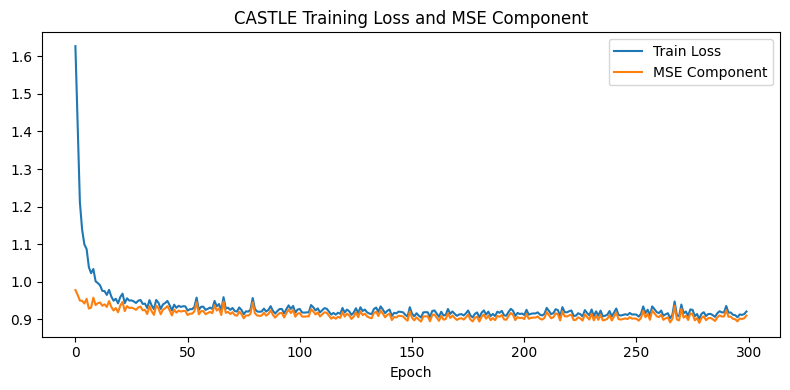

|A| (off-diag): max=0.00083, mean=0.000166
Adaptive edge threshold tau=0.00017 -> 282 directed entries


In [6]:
from pydeepcausalml.discovery import CASTLE

d = Z_train.shape[1]
castle_fit = CASTLE(
    y_index=-1,
    hidden_dim=64,
    num_layers=3,
    lambda_reg=1.0,
    beta_sparsity=0.015,
    acyc_weight=0.1,
    recon_weight=0.5,
    epochs=300 if run_fast else 600,
    batch_size=256,
    lr=1e-3,
    random_state=42,
)
castle_fit.fit(Z_train)

loss_df = pd.DataFrame(castle_fit.history_)
print("Training finished. Last epoch:")
print(loss_df.tail(1))

plt.figure(figsize=(8, 4))
plt.plot(loss_df["loss"], label="Train Loss")
if "mse" in loss_df:
    plt.plot(loss_df["mse"], label="MSE Component")
plt.legend()
plt.title("CASTLE Training Loss and MSE Component")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()

A_est = castle_fit.get_scores()
off = A_est.copy()
np.fill_diagonal(off, 0)
amax, amean = np.abs(off).max(), np.abs(off).mean()
print(f"|A| (off-diag): max={amax:.5f}, mean={amean:.6f}")
A_EDGE_TAU = max(1e-4, 0.2 * amax) if amax > 0 else 0.0
A_thresholded = np.where(np.abs(A_est) > A_EDGE_TAU, A_est, 0.0)
np.fill_diagonal(A_thresholded, 0)
print(f"Adaptive edge threshold tau={A_EDGE_TAU:.5f} -> {(A_thresholded != 0).sum()} directed entries")


### Interpretation and visualization


   variable     score   A_inout   W1_norm
5        x6  0.946440  0.014445  1.178276
0        x1  0.845814  0.012947  1.130707
25        T  0.738352  0.009699  1.319635
24      x25  0.735613  0.012491  0.906150
14      x15  0.734897  0.012129  0.956937
16      x17  0.721731  0.010642  1.138478
4        x5  0.687019  0.009440  1.221843
1        x2  0.634813  0.008863  1.167949
20      x21  0.626063  0.009505  1.051447
13      x14  0.625155  0.009073  1.111946


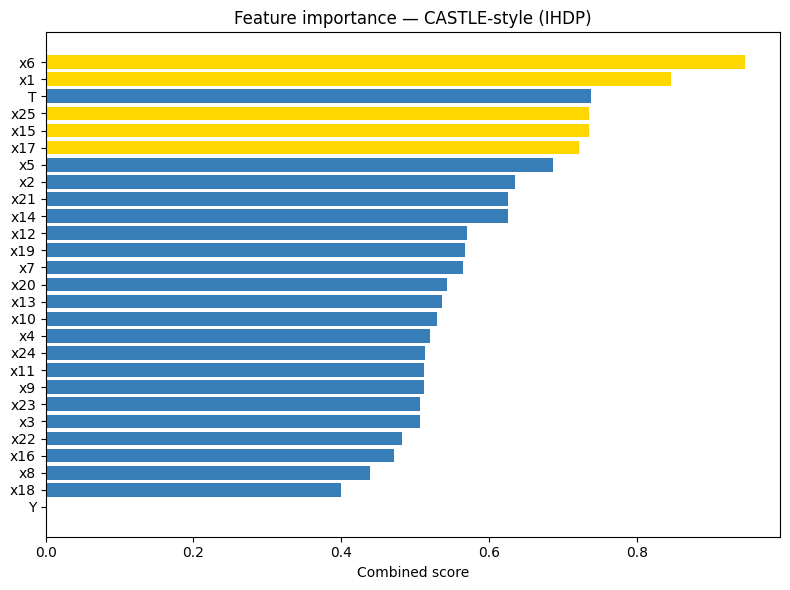

Graph from adaptive threshold tau=0.0001661


/tmp/ipykernel_811/977754548.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


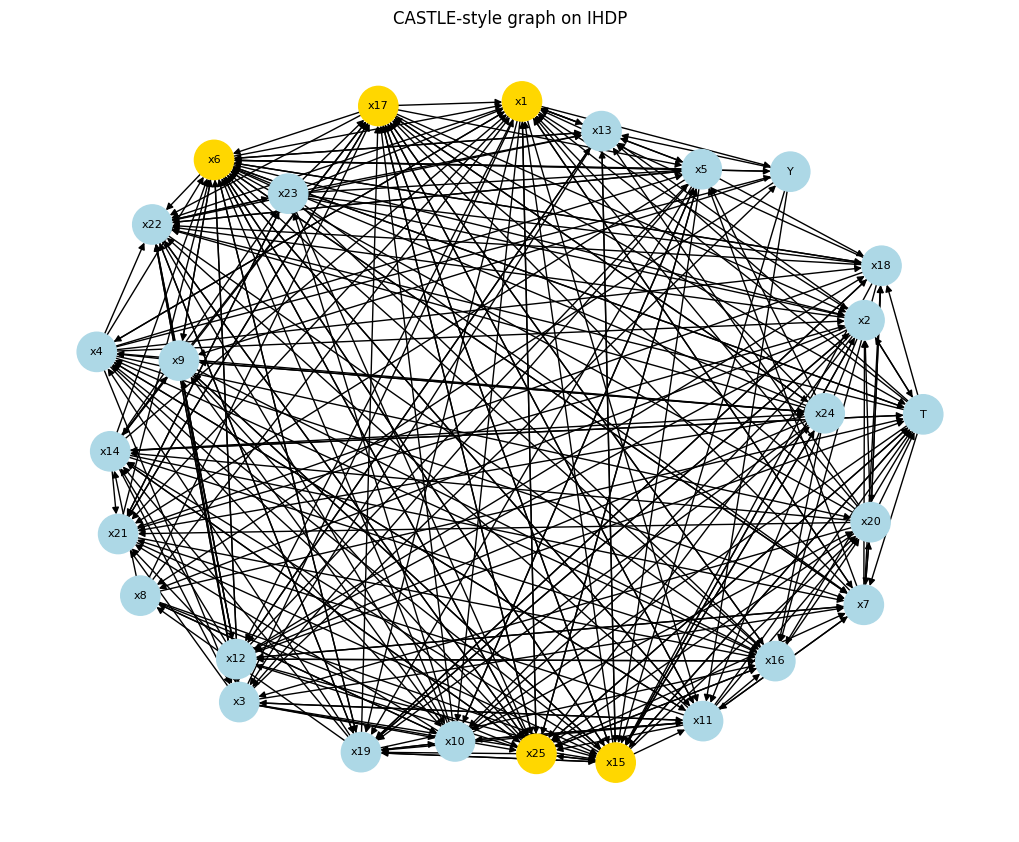

Test predictions shape: (1345,)


In [7]:
node_labels = VAR_NAMES
A = A_est.copy()
np.fill_diagonal(A, 0)
absA = np.abs(A)
in_mass = absA.sum(axis=0)
out_mass = absA.sum(axis=1)
A_inout = in_mass + out_mass

W1 = castle_fit.module_.predictor[0].weight.detach().cpu().numpy()
W1_norm = np.linalg.norm(W1, axis=0)

def minmax(x):
    return (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else np.zeros_like(x)

score = 0.5 * minmax(A_inout) + 0.5 * minmax(W1_norm)
xvars = [i for i, n in enumerate(node_labels) if n.startswith("x")]
top5_idxs = sorted(xvars, key=lambda i: score[i], reverse=True)[:5]
highlight_vars = [node_labels[i] for i in top5_idxs]

importance_df = pd.DataFrame({"variable": node_labels, "score": score, "A_inout": A_inout, "W1_norm": W1_norm})
importance_df = importance_df.sort_values("score", ascending=False)
print(importance_df.head(10))

plt.figure(figsize=(8, 6))
colors = ["gold" if v in highlight_vars else "#377eb8" for v in importance_df["variable"]]
plt.barh(importance_df["variable"], importance_df["score"], color=colors)
plt.title("Feature importance — CASTLE-style (IHDP)")
plt.xlabel("Combined score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

edge_rows = []
for i, fr in enumerate(node_labels):
    for j, to in enumerate(node_labels):
        w = A_thresholded[i, j]
        if i != j and abs(w) > 1e-8:
            edge_rows.append((fr, to, w))
edge_df = pd.DataFrame(edge_rows, columns=["from", "to", "weight"])
if edge_df.empty:
    flat = [(node_labels[i], node_labels[j], abs(A_est[i, j])) for i in range(d) for j in range(d) if i != j]
    edge_df = pd.DataFrame(flat, columns=["from", "to", "weight"]).sort_values("weight", ascending=False).head(45)
    print(f"No edges above tau; showing top {len(edge_df)} |A| edges (exploratory).")
else:
    print(f"Graph from adaptive threshold tau={A_EDGE_TAU:.4g}")

G = nx.DiGraph()
G.add_nodes_from(node_labels)
for _, row in edge_df.iterrows():
    G.add_edge(row["from"], row["to"], weight=row["weight"])
pos = nx.spring_layout(G, seed=42)
node_colors = ["gold" if n in highlight_vars else "lightblue" for n in G.nodes()]
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=800, font_size=8, arrows=True)
plt.title("CASTLE-style graph on IHDP")
plt.tight_layout()
plt.show()

pred_test = castle_fit.predict(Z_test)
print("Test predictions shape:", pred_test.shape)


### Validation (DAGMA-style diagnostics)


In [8]:
def adjacency_to_igraph(W, names, threshold=0):
    W2 = W.copy()
    np.fill_diagonal(W2, 0)
    W2[np.abs(W2) <= threshold] = 0
    G = nx.DiGraph()
    G.add_nodes_from(names)
    for i, fr in enumerate(names):
        for j, to in enumerate(names):
            if W2[i, j] != 0:
                G.add_edge(fr, to, weight=W2[i, j])
    return G


def sem_reconstruction_metrics(W, Zt, model_name=""):
    X_hat = Zt @ W
    mse_pv = ((Zt - X_hat) ** 2).mean(axis=0)
    ss_res = ((Zt - X_hat) ** 2).sum()
    ss_tot = ((Zt - Zt.mean(axis=0)) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {"model": model_name, "mean_MSE": round(mse_pv.mean(), 4), "global_R2": round(r2, 4),
            "mse_T": round(mse_pv[25], 4), "mse_Y": round(mse_pv[26], 4)}


def estimate_ate_adjustment(W, names, trx, trt, try_, tex, tpy, model_name=""):
    G = adjacency_to_igraph(W, names)
    y_parents = [p for p in G.predecessors("Y")]
    par_idx = [names.index(p) for p in y_parents if p not in ("T", "Y") and p in names[:trx.shape[1]]]
    if not par_idx:
        par_idx = list(range(trx.shape[1]))
    idx_t, idx_c = trt == 1, trt == 0
    fit1 = LinearRegression().fit(trx[idx_t][:, par_idx], try_[idx_t])
    fit0 = LinearRegression().fit(trx[idx_c][:, par_idx], try_[idx_c])
    m1 = fit1.predict(tex[:, par_idx])
    m0 = fit0.predict(tex[:, par_idx])
    ah = (m1 - m0).mean()
    oa = (tpy[:, 1] - tpy[:, 0]).mean()
    pehe_val = np.sqrt(((m1 - m0) - (tpy[:, 1] - tpy[:, 0])) ** 2).mean()
    return {"model": model_name, "n_adj_vars": len(par_idx), "ATE_estimated": round(ah, 4),
            "ATE_oracle": round(oa, 4), "ATE_error": round(abs(ah - oa), 4), "sqrt_PEHE": round(pehe_val, 4)}


Graph statistics (CASTLE)
{'nodes': 27, 'edges': 282, 'density': 0.4017, 'isDAG': False}
SEM reconstruction (linear Z @ W, exploratory)
        mean_MSE  global_R2     mse_T  mse_Y
model                                       
CASTLE    5.6228    -0.2062  137.7984    0.0
CASTLE T parents=['x2', 'x6', 'x8', 'x11', 'x12', 'x14', 'x15', 'x17', 'x20', 'x25'] children=['x1', 'x2', 'x6', 'x7', 'x10', 'x13', 'x14', 'x15', 'x16', 'x18', 'x22', 'x25']
CASTLE Y parents=['x1', 'x3', 'x4', 'x6'] children=['x6', 'x8', 'x9', 'x11', 'x13', 'x15']
ATE (linear adjustment on parents of Y in learned graph, IHDP-style)
        n_adj_vars  ATE_estimated  ATE_oracle  ATE_error  sqrt_PEHE
model                                                              
CASTLE           4         4.7803      4.5293     0.2511     4.1547


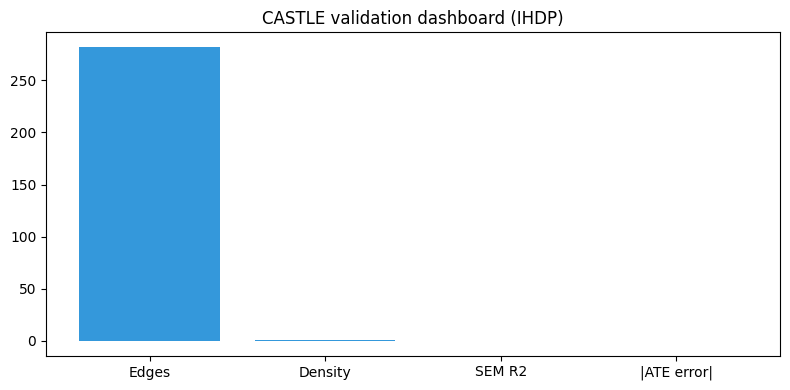

In [9]:
G_castle = adjacency_to_igraph(A_thresholded, VAR_NAMES, threshold=1e-8)
if G_castle.number_of_edges() == 0:
    W_fallback = np.zeros_like(A_est)
    for _, row in edge_df.iterrows():
        i, j = node_labels.index(row["from"]), node_labels.index(row["to"])
        W_fallback[i, j] = row["weight"]
    G_castle = adjacency_to_igraph(W_fallback, VAR_NAMES, threshold=1e-8)

d_n, e_n = G_castle.number_of_nodes(), G_castle.number_of_edges()
density = e_n / (d_n * (d_n - 1)) if d_n > 1 else 0
print("Graph statistics (CASTLE)")
print({"nodes": d_n, "edges": e_n, "density": round(density, 4), "isDAG": nx.is_directed_acyclic_graph(G_castle)})

W_sem = A_est.copy()
np.fill_diagonal(W_sem, 0)
recon_df = pd.DataFrame([sem_reconstruction_metrics(W_sem, Z_test_eval, "CASTLE")]).set_index("model")
print("SEM reconstruction (linear Z @ W, exploratory)")
print(recon_df)

for node in ["T", "Y"]:
    if node in G_castle:
        print(f"CASTLE {node} parents={list(G_castle.predecessors(node))} children={list(G_castle.successors(node))}")

W_ate = A_thresholded.copy()
np.fill_diagonal(W_ate, 0)
if np.abs(W_ate).sum() < 1e-12:
    cut = 1e-6 * max(np.abs(A_est).max(), 1)
    W_ate = np.where(np.abs(A_est) > cut, A_est, 0)
    np.fill_diagonal(W_ate, 0)

ate_df = pd.DataFrame([
    estimate_ate_adjustment(W_ate, VAR_NAMES, train_x, train_t, train_y, test_x, test_potential_y, "CASTLE")
]).set_index("model")
print("ATE (linear adjustment on parents of Y in learned graph, IHDP-style)")
print(ate_df)

dashboard = pd.DataFrame({
    "metric": ["Edges", "Density", "SEM R2", "|ATE error|"],
    "value": [e_n, round(density, 4), recon_df.loc["CASTLE", "global_R2"], ate_df.loc["CASTLE", "ATE_error"]],
})
plt.figure(figsize=(8, 4))
plt.bar(dashboard["metric"], dashboard["value"], color=["#3498db", "#3498db", "#2ecc71", "#e74c3c"])
plt.title("CASTLE validation dashboard (IHDP)")
plt.tight_layout()
plt.show()


## Summary and Conclusions

- **CASTLE (NeurIPS 2020)** ties supervised prediction to a learnable adjacency `A`, selective reconstruction, and a NOTEARS-style acyclicity penalty. This notebook uses **PyDeepCausalML**'s `CASTLE` on IHDP-style matrices with columns $[x_1, \ldots, x_{25}, T, Y]$.



## Resources (CASTLE and related)

- **Paper (NeurIPS 2020):** [CASTLE: Regularization via Auxiliary Causal Graph Discovery](https://arxiv.org/abs/2009.13180)
- **NOTEARS:** [arXiv:1803.01422](https://arxiv.org/abs/1803.01422)
- **PyDeepCausalML:** `pydeepcausalml.discovery.CASTLE`
- **Companion:** `02_08_05_05_03_04_DeepCausalML_DAGMA_NoCurl.ipynb`
